In [1]:
import keras
from keras.models import Sequential
from keras.layers import Dense,BatchNormalization
import pandas as pd
from sklearn.model_selection import train_test_split
from numpy.random import seed


/mnt/disks/user/anaconda3/lib/python3.6/site-packages/h5py/__init__.py:36: FutureWarning: Conversion of the second argument of issubdtype from `float` to `np.floating` is deprecated. In future, it will be treated as `np.float64 == np.dtype(float).type`.
  from ._conv import register_converters as _register_converters
Using TensorFlow backend.


In [2]:
data= pd.read_csv("kdd_train_raw_VAE_KM.csv")




In [3]:
data.head()

,feature_0,feature_1,attack,label_2,label_5,Class_2,Class_5,pred_2,pred_5,pred_lb
0,-0.001652,0.296724,normal,normal,Normal,1,1,1,1,Probe
1,-0.001698,0.033707,normal,normal,Normal,1,1,1,1,Probe
2,-0.002764,-1.294512,neptune,attack,DoS,0,0,0,4,DoS
3,-0.001359,0.959649,normal,normal,Normal,1,1,1,0,Normal
4,0.000162,1.061138,normal,normal,Normal,1,1,1,0,Normal


In [4]:
print(pd.crosstab(data['pred_5'], data['label_5']),"\n")

label_5    DoS  Normal  Probe  R2L  U2R
pred_5                                 
0          817   34945      2    4    0
1         3744   16762   5941   30    7
2         6943    3100   5266   57    1
3          121   12526     38  902   44
4        34302      10    409    2    0 



data['pred_5'].replace("DoS",0,inplace=True)
data['pred_5'].replace("Normal",1,inplace=True)
data['pred_5'].replace("Probe",2,inplace=True)
data['pred_5'].replace("R2L",3,inplace=True)
data['pred_5'].replace("U2R",4,inplace=True)

In [5]:
print(pd.crosstab(data['pred_5'], data['label_5']),"\n")

label_5    DoS  Normal  Probe  R2L  U2R
pred_5                                 
0          817   34945      2    4    0
1         3744   16762   5941   30    7
2         6943    3100   5266   57    1
3          121   12526     38  902   44
4        34302      10    409    2    0 



In [6]:
print(pd.crosstab(data['pred_5'], data['Class_5']),"\n")

Class_5      0      1     2    3   4
pred_5                              
0          817  34945     2    4   0
1         3744  16762  5941   30   7
2         6943   3100  5266   57   1
3          121  12526    38  902  44
4        34302     10   409    2   0 



In [7]:
y=data.pop('pred_5')
X=data

In [8]:
y.value_counts()

0    35768
4    34723
1    26484
2    15367
3    13631
Name: pred_5, dtype: int64

In [9]:
X.head()

,feature_0,feature_1,attack,label_2,label_5,Class_2,Class_5,pred_2,pred_lb
0,-0.001652,0.296724,normal,normal,Normal,1,1,1,Probe
1,-0.001698,0.033707,normal,normal,Normal,1,1,1,Probe
2,-0.002764,-1.294512,neptune,attack,DoS,0,0,0,DoS
3,-0.001359,0.959649,normal,normal,Normal,1,1,1,Normal
4,0.000162,1.061138,normal,normal,Normal,1,1,1,Normal


In [10]:
X.shape

(125973, 9)

In [11]:
label_list=['attack', 'label_2', 'label_5', 'Class_2', 'Class_5', 'pred_2','pred_lb']
X_label=X[label_list]
X.drop(label_list, axis = 1, inplace = True)


In [12]:
X_train, X_val,y_train, y_val = train_test_split(X,y, train_size = 0.7, test_size = 0.3, random_state = seed(100))

In [13]:
# define the keras model
input_dim=X_train.shape[1]
output_dim=5
model = Sequential()
model.add(Dense(10, input_dim=input_dim, activation='elu'))
#model.add(BatchNormalization())
model.add(Dense(8, activation='elu'))
#model.add(BatchNormalization())
model.add(Dense(5, activation='tanh'))
model.add(Dense(output_dim, activation='softmax'))
#model.add(Dense(1, activation='softmax'))


In [14]:
# compile the keras model
opt = keras.optimizers.Adam(lr=0.001)
model.compile(loss='sparse_categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_1 (Dense)              (None, 10)                30        
_________________________________________________________________
dense_2 (Dense)              (None, 8)                 88        
_________________________________________________________________
dense_3 (Dense)              (None, 5)                 45        
_________________________________________________________________
dense_4 (Dense)              (None, 5)                 30        
Total params: 193
Trainable params: 193
Non-trainable params: 0
_________________________________________________________________


In [15]:
import time
start_time = time.time()
history=model.fit(X_train, y_train, epochs = 20, batch_size = 50, shuffle = False, validation_data = (X_val, y_val))

print("\n\nRun Time ->","--- %s seconds ---" % (time.time() - start_time))


Train on 88181 samples, validate on 37792 samples
Epoch 1/20
88181/88181 [==============================] - 9s 100us/step - loss: 0.3524 - acc: 0.8967 - val_loss: 0.0372 - val_acc: 0.9985
Epoch 2/20
88181/88181 [==============================] - 8s 86us/step - loss: 0.0200 - acc: 0.9991 - val_loss: 0.0113 - val_acc: 0.9987
Epoch 3/20
88181/88181 [==============================] - 8s 87us/step - loss: 0.0076 - acc: 0.9991 - val_loss: 0.0058 - val_acc: 0.9987
Epoch 4/20
88181/88181 [==============================] - 8s 87us/step - loss: 0.0042 - acc: 0.9992 - val_loss: 0.0039 - val_acc: 0.9988
Epoch 5/20
88181/88181 [==============================] - 8s 87us/step - loss: 0.0029 - acc: 0.9992 - val_loss: 0.0032 - val_acc: 0.9988
Epoch 6/20
88181/88181 [==============================] - 8s 86us/step - loss: 0.0024 - acc: 0.9992 - val_loss: 0.0029 - val_acc: 0.9989
Epoch 7/20
88181/88181 [==============================] - 8s 86us/step - loss: 0.0022 - acc: 0.9992 - val_loss: 0.0027 - val_ac

In [16]:
import matplotlib.pyplot as plt

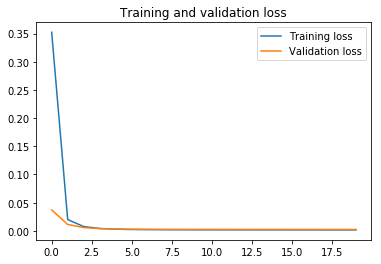

In [17]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(20)
plt.figure()
plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

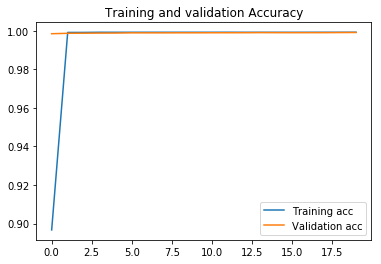

In [70]:
loss = history.history['acc']
val_loss = history.history['val_acc']
epochs = range(20)
plt.figure()
plt.plot(epochs, loss, label='Training acc')
plt.plot(epochs, val_loss, label='Validation acc')
plt.title('Training and validation Accuracy')
plt.legend()
plt.show()

In [19]:
def metrics_df_5(y_train, y_pred):
    
    print("\n*********************************SKLEARN METRICS***********\n")
    import sklearn.metrics
    print(sklearn.metrics.classification_report(y_train,  y_pred),"\n\n")
    

    
    print("Accuracy : \t",sklearn.metrics.accuracy_score(y_train, y_pred,normalize=True))
    
    print('MCC: \t', sklearn.metrics.matthews_corrcoef(y_train, y_pred))
    print('cOHEN kAPPA sCORE: \t',sklearn.metrics.cohen_kappa_score(y_train, y_pred))
    #print('Cross Entropy: \t',sklearn.metrics.sparse_categorical_crossentropy(y_train, y_pred))
    
    
    print("\n************************* MULTI CONFUSION MATRIX***********\n")
    print("Confusion Matrix :\n",sklearn.metrics.confusion_matrix(y_train, y_pred))

    
    cm=sklearn.metrics.confusion_matrix(y_train, y_pred)
    target_names=['DoS','Normal','Probe',"R2L",'U2R']
    plot_confusion_matrix_multi(cm,
                          target_names,
                          title='Confusion matrix',
                          cmap=None,
                          normalize=False)
    

In [20]:
import numpy as np


def plot_confusion_matrix_multi(cm,
                          target_names,
                          title='Confusion matrix',
                          cmap=None,
                          normalize=True):
    """
    given a sklearn confusion matrix (cm), make a nice plot

    Arguments
    ---------
    cm:           confusion matrix from sklearn.metrics.confusion_matrix

    target_names: given classification classes such as [0, 1, 2]
                  the class names, for example: ['high', 'medium', 'low']

    title:        the text to display at the top of the matrix

    cmap:         the gradient of the values displayed from matplotlib.pyplot.cm
                  see http://matplotlib.org/examples/color/colormaps_reference.html
                  plt.get_cmap('jet') or plt.cm.Blues

    normalize:    If False, plot the raw numbers
                  If True, plot the proportions

    Usage
    -----
    plot_confusion_matrix(cm           = cm,                  # confusion matrix created by
                                                              # sklearn.metrics.confusion_matrix
                          normalize    = True,                # show proportions
                          target_names = y_labels_vals,       # list of names of the classes
                          title        = best_estimator_name) # title of graph

    Citiation
    ---------
    http://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html

    """
    import matplotlib.pyplot as plt
    import numpy as np
    import itertools

    accuracy = np.trace(cm) / float(np.sum(cm))
    misclass = 1 - accuracy

    if cmap is None:
        cmap = plt.get_cmap('Blues')

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    if target_names is not None:
        tick_marks = np.arange(len(target_names))
        plt.xticks(tick_marks, target_names, rotation=45)
        plt.yticks(tick_marks, target_names)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


    thresh = cm.max() / 1.5 if normalize else cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        if normalize:
            plt.text(j, i, "{:0.4f}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
        else:
            plt.text(j, i, "{:,}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")


    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label\naccuracy={:0.4f}; misclass={:0.4f}'.format(accuracy, misclass))
    plt.show()

In [21]:
def model_average(y_test, y_pred):
        print("*******************MODEL PAARMETERS*****************")
        #importing accuracy_score, precision_score, recall_score, f1_score
        from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,log_loss,matthews_corrcoef,cohen_kappa_score
        print('Accuracy: \t',accuracy_score(y_test, y_pred))
        #print('\nCross Entropy: {:.2f}\n'.format(sparse_categorical_crossentropy(y_test, y_pred)))
        print('MCC: \t',matthews_corrcoef(y_test, y_pred))
        print('COHEN KAPPA SCORE: \t',cohen_kappa_score(y_test, y_pred))


        print('\nMicro Precision: \t', precision_score(y_test, y_pred, average='micro'))
        print('Micro Recall:  \t',recall_score(y_test, y_pred, average='micro'))
        print('Micro F1-score: \t',f1_score(y_test, y_pred, average='micro'))

        print('\nMacro Precision: \t',precision_score(y_test, y_pred, average='macro'))
        print('Macro Recall:  \t',recall_score(y_test, y_pred, average='macro'))
        print('Macro F1-score: \t',f1_score(y_test, y_pred, average='macro'))

        print('\nWeighted Precision:  \t',precision_score(y_test, y_pred, average='weighted'))
        print('Weighted Recall:   \t',recall_score(y_test, y_pred, average='weighted'))
        print('Weighted F1-score:  \t',f1_score(y_test, y_pred, average='weighted'))


In [22]:
 def attack_metrics(confusion,i=0,attack="DoS")   :  
        
        total=np.sum(confusion)
        TP = confusion[i,i]
            # To get false negatives we count elements not on diagonal
        row_sum = np.sum(confusion[i])
        FN = np.subtract(row_sum, TP)
            # To calculate false positive we sum each row and
            # remove the diagonal from it
        column_sum = np.sum(confusion[:,i])
        FP = np.subtract(column_sum, TP)
        
        TN=total-(TP+FP+FN)
        print(TP,FP,FN,TN)

        #Classification accuracy:
        acc=(TP + TN) / (TP + TN + FP + FN)
        #Error rate:
        error_rate=(FP + FN) / (TP + TN + FP + FN)
        #BCR: Balanced Classification Rate
        bcr=0.5* (TP / (TP + FN) + TN / (TN + FP))

        #Precision: (or Positive predictive value)
        #proportion of predicted positives which are actual positive
        p=TP / (TP + FP)
        #Recall/hitrate
        #proportion of actual positives which are predicted positive
        r=TP / (TP + FN)
        #F1-score
        f1=2*p*r/ (p+r)
        #Specificity: proportion of actual negative which are predicted negative
        specificity=TN / (TN + FP)
        #True negative rate: proportion of actual negative which are predicted negative
        TNR=TN / (TN + FP)    
        
        print("Evaluation metrics for category ",attack)
        # Let's see the sensitivity of our logistic regression model
        print('Accuracy: \t',acc)
        print('Error Rate: \t',error_rate)
        print('Balanced Accuracy: \t',bcr)


        print('Recall: \t',r)
        # Let us calculate precision
        print('Precision:  \t',p)
        print('F1-SCORE:  \t',f1)
        # Let us calculate specificity
        print('Specificity : \t',specificity)
        
        print('False Alarm Rate:  \t',(FP/ float(TN+FP)))
        #False Negative
        print('False Negative Rate:  \t',(FN/ float(TP+FN)))

In [41]:
pred = model.predict_classes(X)

In [43]:
y_train=X_label['Class_5']

In [44]:
y_train.value_counts()

1    67343
0    45927
2    11656
3      995
4       52
Name: Class_5, dtype: int64

In [45]:
X_label['pred']=pred

/mnt/disks/user/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  """Entry point for launching an IPython kernel.


In [46]:
X_label['pred'].value_counts()

0    35796
4    34718
1    26567
2    15364
3    13528
Name: pred, dtype: int64

In [47]:
print(pd.crosstab(X_label['label_5'], X_label['pred']),"\n")


pred         0      1     2      3      4
label_5                                  
DoS        818   3750  6944    118  34297
Normal   34972  16834  3099  12428     10
Probe        2   5946  5263     36    409
R2L          4     30    57    902      2
U2R          0      7     1     44      0 



In [48]:
X_label['pred'].replace(4,"DoS",inplace=True)
X_label['pred'].replace(0,"Normal",inplace=True)
X_label['pred'].replace(1,"Probe",inplace=True)
X_label['pred'].replace(3,"R2L",inplace=True)
X_label['pred'].replace(2,"U2R",inplace=True)

/mnt/disks/user/anaconda3/lib/python3.6/site-packages/pandas/core/generic.py:5890: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  self._update_inplace(new_data)


In [49]:
print(pd.crosstab(X_label['label_5'], X_label['pred']),"\n")


pred       DoS  Normal  Probe    R2L   U2R
label_5                                   
DoS      34297     818   3750    118  6944
Normal      10   34972  16834  12428  3099
Probe      409       2   5946     36  5263
R2L          2       4     30    902    57
U2R          0       0      7     44     1 




*********************************SKLEARN METRICS***********

             precision    recall  f1-score   support

        DoS       0.99      0.75      0.85     45927
     Normal       0.98      0.52      0.68     67343
      Probe       0.22      0.51      0.31     11656
        R2L       0.07      0.91      0.12       995
        U2R       0.00      0.02      0.00        52

avg / total       0.90      0.60      0.70    125973
 


Accuracy : 	 0.6042405912378049
MCC: 	 0.4983461095073595
cOHEN kAPPA sCORE: 	 0.4557805883928193

************************* MULTI CONFUSION MATRIX***********

Confusion Matrix :
 [[34297   818  3750   118  6944]
 [   10 34972 16834 12428  3099]
 [  409     2  5946    36  5263]
 [    2     4    30   902    57]
 [    0     0     7    44     1]]


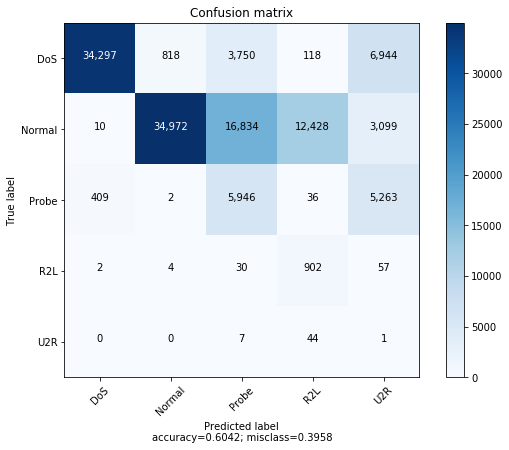

In [50]:
metrics_df_5(X_label['label_5'], X_label['pred'])

In [51]:
model_average(X_label['label_5'], X_label['pred'])

*******************MODEL PAARMETERS*****************
Accuracy: 	 0.6042405912378049
MCC: 	 0.4983461095073595
COHEN KAPPA SCORE: 	 0.4557805883928193

Micro Precision: 	 0.6042405912378049
Micro Recall:  	 0.6042405912378049
Micro F1-score: 	 0.6042405912378049

Macro Precision: 	 0.45108149982497264
Macro Recall:  	 0.5403941218700699
Macro F1-score: 	 0.3928376312437005

Weighted Precision:  	 0.903669667667041
Weighted Recall:   	 0.6042405912378049
Weighted F1-score:  	 0.7023956156589539


###  ATTACK metrics

In [71]:
import sklearn
confusion=sklearn.metrics.confusion_matrix(X_label['label_5'], X_label['pred'])
print(confusion)


[[34297   818  3750   118  6944]
 [   10 34972 16834 12428  3099]
 [  409     2  5946    36  5263]
 [    2     4    30   902    57]
 [    0     0     7    44     1]]


In [72]:
attack_metrics(confusion,0,attack="DOS")

34297 421 11630 79625
Evaluation metrics for category  DOS
Accuracy: 	 0.9043366435664786
Error Rate: 	 0.09566335643352147
Balanced Accuracy: 	 0.8707562877486931
Recall: 	 0.7467720512988003
Precision:  	 0.9878737254450141
F1-SCORE:  	 0.8505673011346022
Specificity : 	 0.9947405241985858
False Alarm Rate:  	 0.005259475801414187
False Negative Rate:  	 0.25322794870119975


In [73]:
attack_metrics(confusion,1,attack="Normal")

34972 824 32371 57806
Evaluation metrics for category  Normal
Accuracy: 	 0.7364911528660903
Error Rate: 	 0.26350884713390965
Balanced Accuracy: 	 0.7526286727680176
Recall: 	 0.5193115839805177
Precision:  	 0.9769806682310873
F1-SCORE:  	 0.678152784106885
Specificity : 	 0.9859457615555176
False Alarm Rate:  	 0.014054238444482347
False Negative Rate:  	 0.48068841601948237


In [74]:
attack_metrics(confusion,2,attack="Probe")

5946 20621 5710 93696
Evaluation metrics for category  Probe
Accuracy: 	 0.7909790193136624
Error Rate: 	 0.20902098068633754
Balanced Accuracy: 	 0.6648695858724529
Recall: 	 0.5101235415236788
Precision:  	 0.22381149546429782
F1-SCORE:  	 0.31112157601444157
Specificity : 	 0.819615630221227
False Alarm Rate:  	 0.18038436977877306
False Negative Rate:  	 0.4898764584763212


In [75]:
attack_metrics(confusion,3,attack="R2L")

902 12626 93 112352
Evaluation metrics for category  R2L
Accuracy: 	 0.899033919966977
Error Rate: 	 0.10096608003302295
Balanced Accuracy: 	 0.9027534413896041
Recall: 	 0.9065326633165829
Precision:  	 0.06667652276759314
F1-SCORE:  	 0.1242167596226675
Specificity : 	 0.8989742194626255
False Alarm Rate:  	 0.10102578053737458
False Negative Rate:  	 0.09346733668341708


In [76]:
attack_metrics(confusion,4,attack="U2R")

1 15363 51 110558
Evaluation metrics for category  U2R
Accuracy: 	 0.8776404467624015
Error Rate: 	 0.12235955323759853
Balanced Accuracy: 	 0.44861285128099243
Recall: 	 0.019230769230769232
Precision:  	 6.508721687060662e-05
F1-SCORE:  	 0.00012973533990659058
Specificity : 	 0.8779949333312156
False Alarm Rate:  	 0.1220050666687844
False Negative Rate:  	 0.9807692307692307


In [77]:
#attack_metrics(confusion,5,attack="U2R")

### test data

In [59]:
test_data= pd.read_csv("kdd_test_raw_VAE.csv")

In [60]:
test_data.head()

,feature_0,feature_1,attack,label_2,label_5
0,1.575795,0.070001,neptune,attack,DoS
1,1.588168,0.073355,neptune,attack,DoS
2,-0.042037,0.176596,normal,normal,Normal
3,-0.049919,0.358898,saint,attack,Probe
4,0.885183,0.570391,mscan,attack,Probe


In [61]:
test_data['Class_5']=test_data['label_5']
test_data['Class_5'].replace("DoS",0,inplace=True)
test_data['Class_5'].replace("Normal",1,inplace=True)
test_data['Class_5'].replace("Probe",2,inplace=True)
test_data['Class_5'].replace("R2L",3,inplace=True)
test_data['Class_5'].replace("U2R",4,inplace=True)
test_data['Class_5'].value_counts()

1          9711
0          7167
3          2885
2          2421
unknown     293
4            67
Name: Class_5, dtype: int64

In [62]:
label_list=['attack', 'label_2','label_5','Class_5']
kdd_test_label=test_data[label_list]
test_data.drop(label_list, axis = 1, inplace = True)

In [63]:
y_test=kdd_test_label['Class_5']

In [64]:
test_data.shape

(22544, 2)

In [65]:
import time
start_time=time.time()
pred_t = model.predict_classes(test_data)
print("\n\nRun Time ->","--- %s seconds ---" % (time.time() - start_time))




Run Time -> --- 0.5547635555267334 seconds ---


In [66]:
kdd_test_label['pred']=pred_t

/mnt/disks/user/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  """Entry point for launching an IPython kernel.


In [78]:
kdd_test_label['pred'].value_counts()

1    18547
2     2257
4     1615
3      125
Name: pred, dtype: int64

In [79]:
print(pd.crosstab(kdd_test_label['label_5'], kdd_test_label['pred']),"\n")


pred        1     2   3     4
label_5                      
DoS      3661  2002   1  1503
Normal   9687     7  17     0
Probe    1978   240  91   112
R2L      2861     8  16     0
U2R        67     0   0     0
unknown   293     0   0     0 



test_pred=kdd_test_label['pred'].apply(lambda x: 0 if x==1 else 1)
test_pred.value_counts()

In [80]:
test_pred=kdd_test_label['pred']

In [81]:
kdd_test_label['pred'].replace(2,"DoS",inplace=True)
kdd_test_label['pred'].replace(1,"Normal",inplace=True)
kdd_test_label['pred'].replace(4,"Probe",inplace=True)
kdd_test_label['pred'].replace(3,"R2L",inplace=True)
kdd_test_label['pred'].replace(0,"U2R",inplace=True)

/mnt/disks/user/anaconda3/lib/python3.6/site-packages/pandas/core/generic.py:5890: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  self._update_inplace(new_data)


In [82]:
kdd_test_label['pred'].value_counts()

Normal    18547
DoS        2257
Probe      1615
R2L         125
Name: pred, dtype: int64

In [83]:
print(pd.crosstab(kdd_test_label['label_5'], kdd_test_label['pred']),"\n")


pred      DoS  Normal  Probe  R2L
label_5                          
DoS      2002    3661   1503    1
Normal      7    9687      0   17
Probe     240    1978    112   91
R2L         8    2861      0   16
U2R         0      67      0    0
unknown     0     293      0    0 




*********************************SKLEARN METRICS***********

             precision    recall  f1-score   support

        DoS       0.89      0.28      0.42      7167
     Normal       0.52      1.00      0.69      9711
      Probe       0.07      0.05      0.06      2421
        R2L       0.13      0.01      0.01      2885
        U2R       0.00      0.00      0.00        67
    unknown       0.00      0.00      0.00       293

avg / total       0.53      0.52      0.44     22544
 


Accuracy : 	 0.5241749467707594
MCC: 	 0.28201483031560054


/mnt/disks/user/anaconda3/lib/python3.6/site-packages/sklearn/metrics/classification.py:1135: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)


cOHEN kAPPA sCORE: 	 0.214011382639557

************************* MULTI CONFUSION MATRIX***********

Confusion Matrix :
 [[2002 3661 1503    1    0    0]
 [   7 9687    0   17    0    0]
 [ 240 1978  112   91    0    0]
 [   8 2861    0   16    0    0]
 [   0   67    0    0    0    0]
 [   0  293    0    0    0    0]]


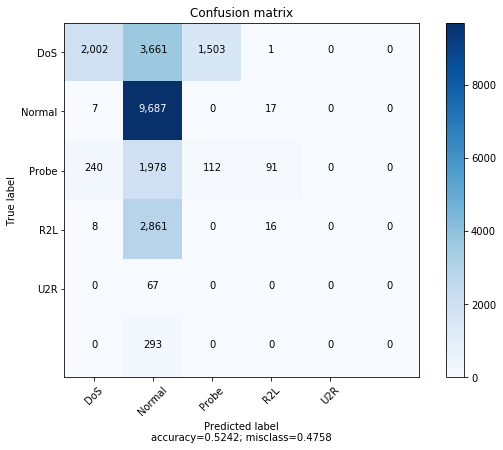

In [84]:
metrics_df_5(kdd_test_label['label_5'], kdd_test_label['pred'])

In [85]:
model_average(kdd_test_label['label_5'], kdd_test_label['pred'])

*******************MODEL PAARMETERS*****************
Accuracy: 	 0.5241749467707594
MCC: 	 0.28201483031560054
COHEN KAPPA SCORE: 	 0.214011382639557

Micro Precision: 	 0.5241749467707594
Micro Recall:  	 0.5241749467707594
Micro F1-score: 	 0.5241749467707594


/mnt/disks/user/anaconda3/lib/python3.6/site-packages/sklearn/metrics/classification.py:1135: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
/mnt/disks/user/anaconda3/lib/python3.6/site-packages/sklearn/metrics/classification.py:1135: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)



Macro Precision: 	 0.26777712027380307
Macro Recall:  	 0.22144537052568633
Macro F1-score: 	 0.1961025907790317

Weighted Precision:  	 0.5308037218239249
Weighted Recall:   	 0.5241749467707594
Weighted F1-score:  	 0.4377248984190377


###  ATTACK metrics

In [93]:
confusion=sklearn.metrics.confusion_matrix(kdd_test_label['label_5'], kdd_test_label['pred'])
print(confusion)

[[2002 3661 1503    1    0    0]
 [   7 9687    0   17    0    0]
 [ 240 1978  112   91    0    0]
 [   8 2861    0   16    0    0]
 [   0   67    0    0    0    0]
 [   0  293    0    0    0    0]]


In [94]:
attack_metrics(confusion,0,attack="DOS")

2002 255 5165 15122
Evaluation metrics for category  DOS
Accuracy: 	 0.7595812633073101
Error Rate: 	 0.24041873669268984
Balanced Accuracy: 	 0.6313763180780626
Recall: 	 0.27933584484442586
Precision:  	 0.8870181657066903
F1-SCORE:  	 0.4248726655348048
Specificity : 	 0.9834167913116993
False Alarm Rate:  	 0.01658320868830071
False Negative Rate:  	 0.7206641551555741


In [95]:
attack_metrics(confusion,1,attack="Normal")

9687 8860 24 3973
Evaluation metrics for category  Normal
Accuracy: 	 0.6059261887863733
Error Rate: 	 0.39407381121362667
Balanced Accuracy: 	 0.6535605163943813
Recall: 	 0.9975285758418289
Precision:  	 0.5222947107348898
F1-SCORE:  	 0.6856111543633662
Specificity : 	 0.3095924569469337
False Alarm Rate:  	 0.6904075430530663
False Negative Rate:  	 0.002471424158171146


In [96]:
attack_metrics(confusion,2,attack="Probe")

112 1503 2309 18620
Evaluation metrics for category  Probe
Accuracy: 	 0.8309084457061746
Error Rate: 	 0.1690915542938254
Balanced Accuracy: 	 0.48578561138547705
Recall: 	 0.04626187525815779
Precision:  	 0.0693498452012384
F1-SCORE:  	 0.05550049554013875
Specificity : 	 0.9253093475127963
False Alarm Rate:  	 0.07469065248720369
False Negative Rate:  	 0.9537381247418422


In [97]:
attack_metrics(confusion,3,attack="R2L")

16 109 2869 19550
Evaluation metrics for category  R2L
Accuracy: 	 0.867902767920511
Error Rate: 	 0.132097232079489
Balanced Accuracy: 	 0.5000006964498601
Recall: 	 0.005545927209705373
Precision:  	 0.128
F1-SCORE:  	 0.0106312292358804
Specificity : 	 0.9944554656900148
False Alarm Rate:  	 0.005544534309985249
False Negative Rate:  	 0.9944540727902946


In [98]:
attack_metrics(confusion,4,attack="U2R")

0 0 67 22477
Evaluation metrics for category  U2R
Accuracy: 	 0.997028034066714
Error Rate: 	 0.0029719659332860184
Balanced Accuracy: 	 0.5
Recall: 	 0.0
Precision:  	 nan
F1-SCORE:  	 nan
Specificity : 	 1.0
False Alarm Rate:  	 0.0
False Negative Rate:  	 1.0


/mnt/disks/user/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:25: RuntimeWarning: invalid value encountered in long_scalars


In [99]:
attack_metrics(confusion,5,attack="unknown")

0 0 293 22251
Evaluation metrics for category  unknown
Accuracy: 	 0.9870031937544358
Error Rate: 	 0.01299680624556423
Balanced Accuracy: 	 0.5
Recall: 	 0.0
Precision:  	 nan
F1-SCORE:  	 nan
Specificity : 	 1.0
False Alarm Rate:  	 0.0
False Negative Rate:  	 1.0


/mnt/disks/user/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:25: RuntimeWarning: invalid value encountered in long_scalars
